#IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs) FOR IMAGE CLASSIFICATION
by Rohith John M | 24BAD100

In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [5]:
# Downloading the dataset (CIFAR-10 is built into Keras)
(train_images_full, train_labels_full), (test_images, test_labels) = datasets.cifar10.load_data()
print("Download complete")
# Preprocessing: Normalize pixel values to be between 0 and 1
train_images_full = train_images_full / 255.0
test_images = test_images / 255.0

# Split dataset into training and validation sets (using 5000 images for validation)
val_images = train_images_full[:5000]
val_labels = train_labels_full[:5000]
train_images = train_images_full[5000:]
train_labels = train_labels_full[5000:]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3627s 21us/step
Download complete


In [6]:
# Building the CNN architecture
model = models.Sequential([
    # Convolutional layers with ReLU activation and Max Pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    # Fully Connected layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # Softmax output layer for 10 classes
    layers.Dense(10, activation='softmax')
])

# Compiling the model with optimizer and cross-entropy loss
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


Initiating Model Training...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 43ms/step - accuracy: 0.4478 - loss: 1.5096 - val_accuracy: 0.5762 - val_loss: 1.2050
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.5934 - loss: 1.1474 - val_accuracy: 0.6080 - val_loss: 1.1167
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6511 - loss: 0.9950 - val_accuracy: 0.6604 - val_loss: 0.9682
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.6866 - loss: 0.8963 - val_accuracy: 0.6752 - val_loss: 0.9227
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.7112 - loss: 0.8264 - val_accuracy: 0.6770 - val_loss: 0.9552
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - accuracy: 0.7321 - loss: 0.7659 - val_accuracy: 0.6994 - val_loss: 0.8759
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accuracy: 0.7497 - loss: 0.7161 - val_accuracy: 0.6978 - val_loss: 0.8626
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 

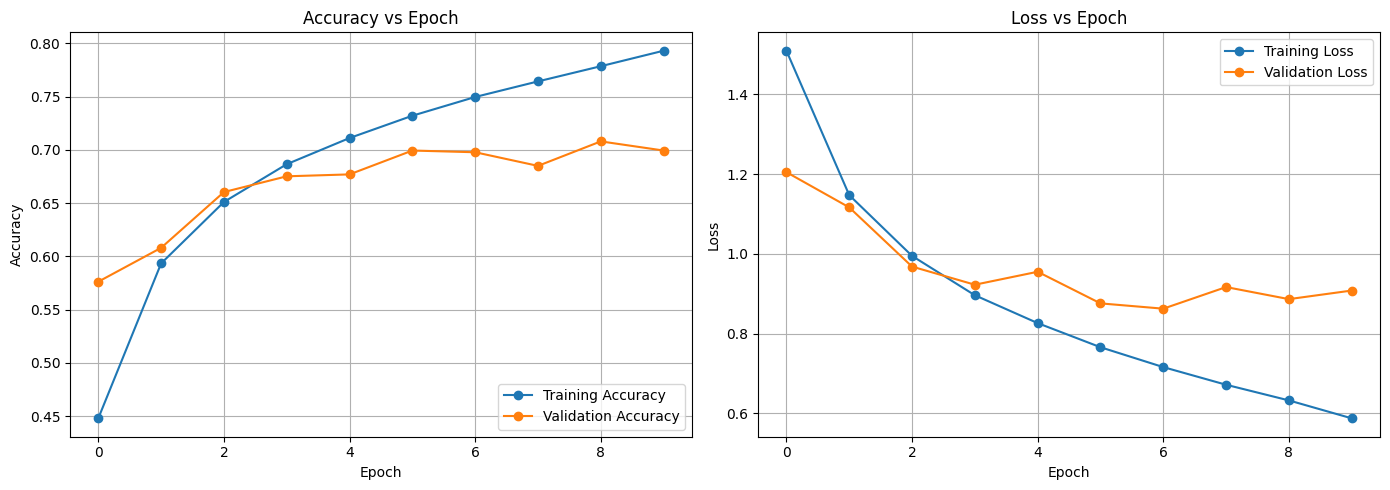

In [7]:
print("\nInitiating Model Training...")
# Train the model and record history
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(val_images, val_labels))

# Evaluate on testing set
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nFinal Testing Accuracy: {test_acc:.4f}')

# Plotting Accuracy and Loss vs Epoch
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


Generating Predictions for Analysis...
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


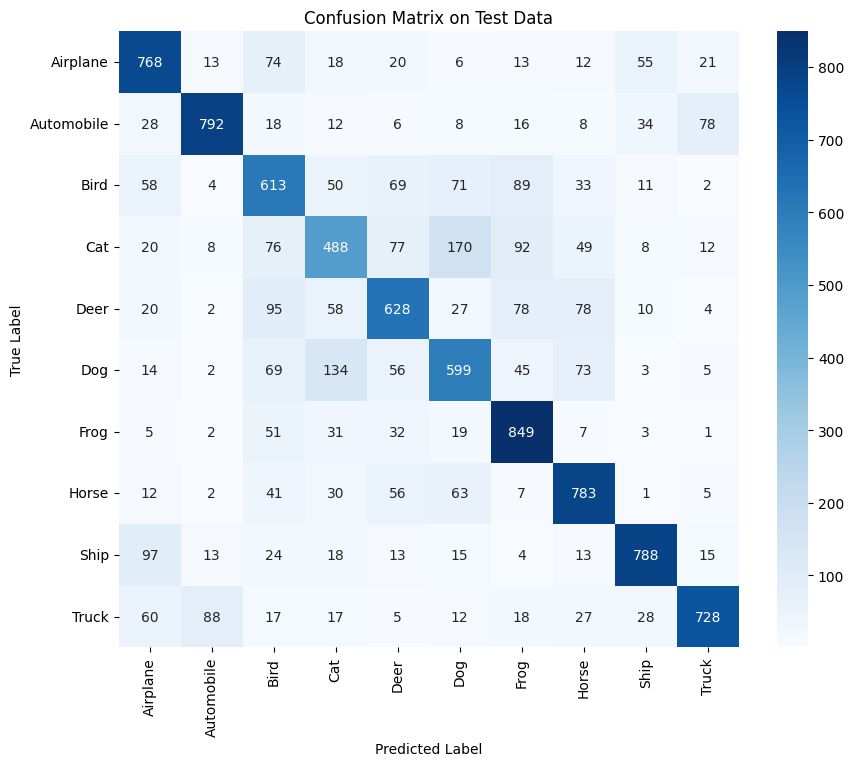


Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

    Airplane       0.71      0.77      0.74      1000
  Automobile       0.86      0.79      0.82      1000
        Bird       0.57      0.61      0.59      1000
         Cat       0.57      0.49      0.53      1000
        Deer       0.65      0.63      0.64      1000
         Dog       0.61      0.60      0.60      1000
        Frog       0.70      0.85      0.77      1000
       Horse       0.72      0.78      0.75      1000
        Ship       0.84      0.79      0.81      1000
       Truck       0.84      0.73      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



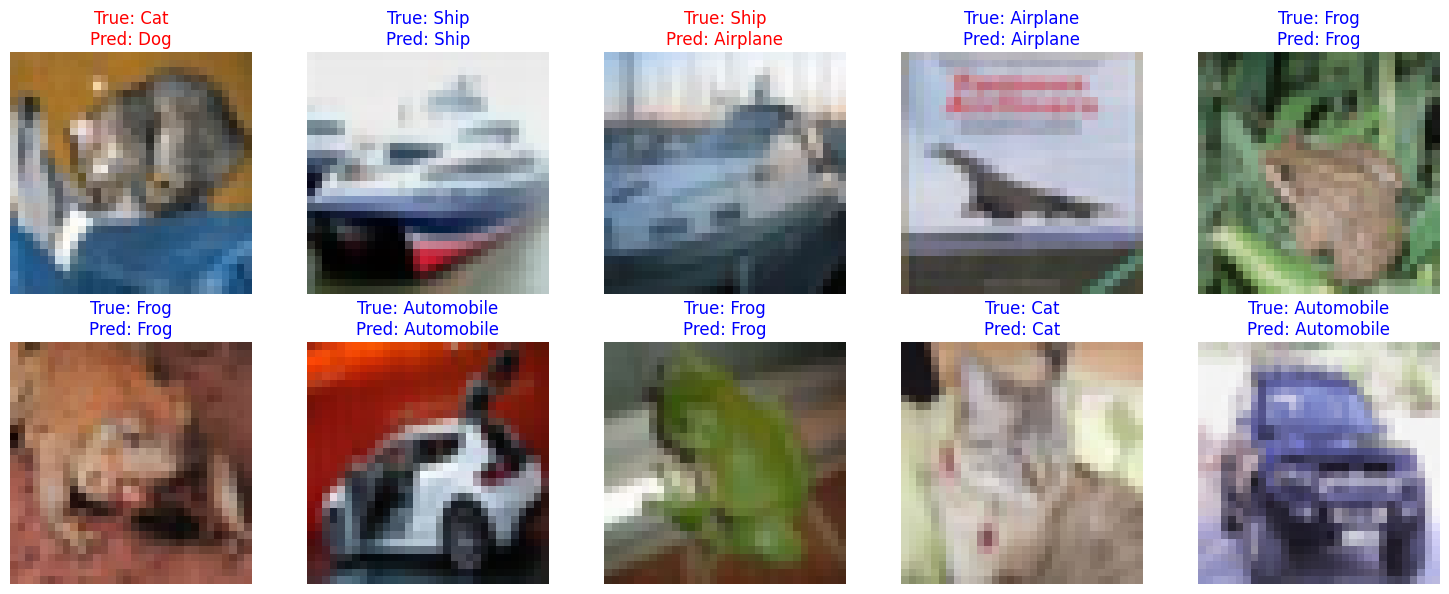

In [10]:
print("\nGenerating Predictions for Analysis...")
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

# Define the CIFAR-10 class names explicitly
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Generate and plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Data')
plt.show()

print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(test_labels, predicted_classes, target_names=class_names))

# Visualize Sample Predictions (including misclassified ones)
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_images[i])
    true_label = class_names[test_labels[i][0]]
    pred_label = class_names[predicted_classes[i]]

    # Highlight misclassifications in red
    color = 'blue' if true_label == pred_label else 'red'

    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()